# <b><font color='chocolate'>Summary</font></b>

### <b><font color='chocolate'>1. Crosstab</font></b>

In [1]:
import pandas as pd

In [2]:
# Любимые цвета людей
df_colors = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'blue', 'red']
})

# Любимые животные людей
df_animals = pd.DataFrame({
    'animal': ['cat', 'dog', 'dog', 'cat', 'bird']
})

In [3]:
pd.crosstab(
    df_colors['color'],
    df_animals['animal']
)

animal,bird,cat,dog
color,,,
blue,0,1,1
green,0,0,1
red,1,1,0


### <b><font color='chocolate'>2. Практическая задача «Исследование контента Netflix»</font></b>

<b>Описание набора данных</b><br>
Этот датасет содержит информацию о фильмах и сериалах, доступных на платформе Netflix по состоянию на середину 2021 года. 

<b>Основные столбцы (Features):</b><br>
- <i>show_id:</i> Уникальный идентификатор каждой записи (строки).
- <i>type:</i> Тип контента. Имеет два значения: Movie (Фильм) или TV Show (Сериал).
- <i>title:</i> Название произведения.
- <i>director:</i> Режиссер (в некоторых записях может быть несколько имен через запятую или пропуски).
- <i>cast:</i> Актерский состав.
- <i>country:</i> Страна или список стран, где был произведен контент.
- <i>date_added:</i> Дата добавления контента в библиотеку Netflix.
- <i>release_year:</i> Фактический год выхода фильма или сериала в прокат.
- <i>rating:</i> Возрастной рейтинг (например, TV-MA, PG-13, TV-14).
- <i>duration:</i> Продолжительность. Для фильмов указывается в минутах (min), для сериалов — в количестве сезонов (Seasons).
- <i>listed_in:</i> Жанры и категории (например, "Documentaries", "International TV Shows").
- <i>description:</i> Краткое описание сюжета.

In [4]:
# Импорт необходимых библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  

In [5]:
# Загрузка данных в DataFrame df_netflix
df_netflix = pd.read_csv('netflix_titles.csv')
df_netflix

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


<b>Задание 1: Линейный график. Эволюция производства контента</b>
- <i>Подготовка в Pandas:</i> Сгруппируйте данные по столбцу release_year и посчитайте количество вышедших тайтлов. Отфильтруйте данные, оставив период с 2000 по 2021 год.
- <i>Визуализация:</i> Постройте линейный график динамики количества релизов.
- <i>Требования:</i> Цвет линии — фирменный красный Netflix (#E50914), толщина линии — 2, добавьте маркеры в точках данных.

In [ ]:
# 1. Подготовка в Pandas
# Сгруппированные и отфильтрованные данные назовите yearly_counts
df_netflix_group = df_netflix.groupby('release_year',)['title'].count()
yearly_counts = df_netflix_group.loc[2000:2021]
yearly_counts

In [ ]:
df_netflix_group = df_netflix.groupby('release_year',as_index = False)['title'].count()
yearly_counts = df_netflix_group[(df_netflix_group['release_year']>=2000)&(df_netflix_group['release_year']<=2021)]\
.rename(columns = {'title': 'quantity of title'})
yearly_counts

In [17]:
# 1. Подготовка в Pandas
# Сгруппированные и отфильтрованные данные назовите yearly_counts
yearly_counts = df_netflix.loc[(df_netflix['release_year'] >= 2000) & (df_netflix['release_year'] <= 2020)].groupby('release_year', as_index=False)['title'].count()
yearly_counts

,release_year,title
0,2000,37
1,2001,45
2,2002,51
3,2003,61
4,2004,64
5,2005,80
6,2006,96
7,2007,88
8,2008,136
9,2009,152


In [36]:
yearly_counts = (
    df_netflix.loc[(df_netflix['release_year'] >= 2000) & (df_netflix['release_year'] <= 2021)]
    .groupby('release_year', as_index=False)['title']
    .count()
    .sort_values(by='release_year')
    .rename(columns={'title': 'quantity_title'})
)
yearly_counts

,release_year,quantity_title
0,2000,37
1,2001,45
2,2002,51
3,2003,61
4,2004,64
5,2005,80
6,2006,96
7,2007,88
8,2008,136
9,2009,152


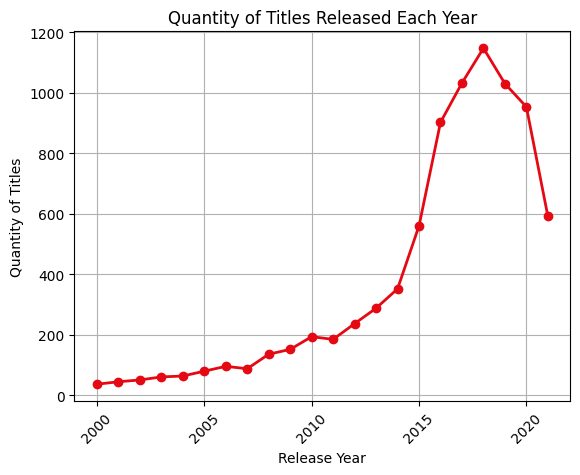

In [37]:
# 2. Визуализация
plt.plot(yearly_counts['release_year'], yearly_counts['quantity_title'], color='#E50914', linewidth=2, marker='o')
plt.xlabel('Release Year')
plt.ylabel('Quantity of Titles')
plt.title('Quantity of Titles Released Each Year')
plt.xticks(rotation=45)
plt.grid()
plt.show()

<b>Задание 2: Столбчатая диаграмма. География производства</b>
- <i>Подготовка в Pandas:</i> Столбец country часто содержит список стран через запятую. Вам нужно:
    - Очистить пропуски.
    - Разбить строки и посчитать, сколько раз встречается каждая страна. Для разбиения строк используйте функцию <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html" title="Explode">explode</a>
    - Выделить Топ-10 стран.
- <i>Визуализация:</i> Постройте горизонтальную столбчатую диаграмму (barh).
- <i>Требования:</i> Расположите страны по убыванию.

In [42]:
# 1. Подготовка в Pandas
# Удалите пропущенные значения в столбце country. Полученный объект назовите countries 
countries = df_netflix['country'].dropna().str.split(', ')
countries

0                                         [United States]
1                                          [South Africa]
4                                                 [India]
7       [United States, Ghana, Burkina Faso, United Ki...
8                                        [United Kingdom]
                              ...                        
8801                       [United Arab Emirates, Jordan]
8802                                      [United States]
8804                                      [United States]
8805                                      [United States]
8806                                              [India]
Name: country, Length: 7976, dtype: object

In [41]:
# Превратите списки в отдельные строки и назовите получившийся объект all_countries
all_countries = countries.explode().reset_index(drop=True)
all_countries

0        United States
1         South Africa
2                India
3        United States
4                Ghana
             ...      
10009           Jordan
10010    United States
10011    United States
10012    United States
10013            India
Name: country, Length: 10014, dtype: object

In [44]:
# Выделите топ-10 стран по количеству тайтлов и назовите получившийся объект top_10_countries
top_10_countries = all_countries.value_counts().head(10)
top_10_countries

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

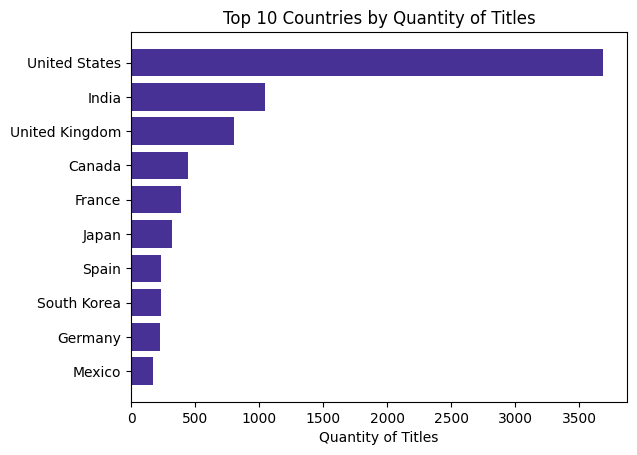

In [46]:
# 2. Визуализация
plt.barh(top_10_countries.index, top_10_countries.values, color="#483194")
plt.xlabel('Quantity of Titles')
plt.title('Top 10 Countries by Quantity of Titles')
plt.gca().invert_yaxis()  # Инвертируем ось Y для отображения с наибольшим значением сверху
plt.show()

<b>Задание 3: Круговая диаграмма. Фильмы vs Сериалы</b>
- <i>Подготовка в Pandas:</i> Посчитайте распределение типов контента.
- <i>Визуализация:</i> Постройте круговую диаграмму.
- <i>Требования:</i> Используйте параметр explode, чтобы немного отделить меньший сектор. Добавьте тень и отобразите проценты с одним знаком после запятой.

In [47]:
# 1. Подготовка данных в Pandas. 
# Распределение типов контента назовите type_counts
type_counts = df_netflix['type'].value_counts()
type_counts

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

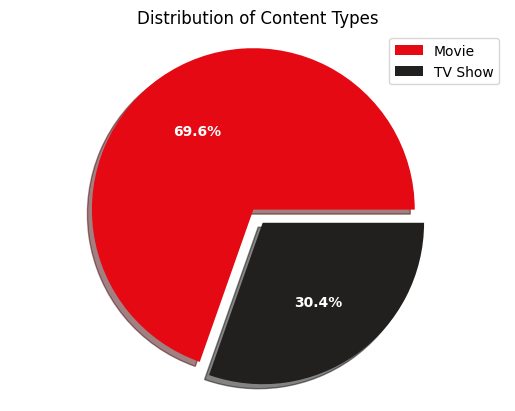

In [ ]:
# 2. Визуализация
plt.pie(type_counts.values, labels=type_counts.index, explode=[0.1, 0], shadow=True, autopct='%1.1f%%', colors=["#E50914", "#221f1f"], textprops={'color': 'white', 'weight': 'bold'})
plt.title('Distribution of Content Types')
plt.legend(loc='upper right')
# plt.legend(labels, loc='center left', bbox_to_anchor=(1, 0.5))
plt.axis('equal')  
plt.show()

<b>Задание 4: Гистограмма. Длительность фильмов</b>
- <i>Подготовка в Pandas:</i>
    1. Создайте подмножество данных, где type == 'Movie'.
    2. Извлеките числовое значение из столбца duration (например, из "90 min" нужно получить 90).
- <i>Визуализация:</i> Постройте гистограмму распределения длительности фильмов.
- <i>Требования:</i> Подберите оптимальное количество bins, добавьте подпись осей. С помощью plt.axvline нарисуйте вертикальную линию, соответствующую средней длительности фильма, и подпишите её в легенде.

In [ ]:
# Отфильтруйте только фильмы из основного датасета и получившийся датасет сохраните в датафрейме movies
movies = df_netflix[df_netflix['type'] == 'Movie'].dropna(subset=['duration'])



0        90
6        91
7       125
9       104
12      127
       ... 
8801     96
8802    158
8804     88
8805     88
8806    111
Name: duration, Length: 6128, dtype: int64

In [62]:
# Извлекаем число из строки с длительностью фильма в новый столбец duration_min
# Подсказка: используйте str.replace
# Получившийся тип данных переведите в тип данных float
movies_duration = movies['duration'].str.replace(' min', '').astype(float)
movies_duration

0        90.0
6        91.0
7       125.0
9       104.0
12      127.0
        ...  
8801     96.0
8802    158.0
8804     88.0
8805     88.0
8806    111.0
Name: duration, Length: 6128, dtype: float64

In [66]:
# Посчитайте среднее значение продолжительности фильма в переменную mean_duration
mean_duration = movies_duration.mean()
print(round(mean_duration, 2))

99.58


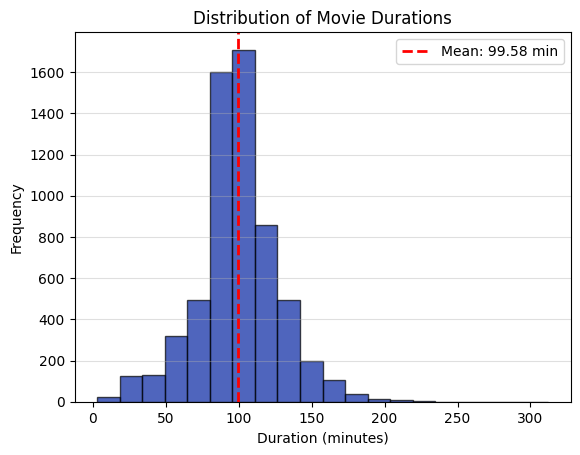

In [82]:
# 2. Визуализация
plt.hist(movies_duration, bins=20, color="#0524A1", edgecolor='black', alpha=0.7)
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Movie Durations')
plt.grid(axis='y', alpha=0.4)
plt.axvline(mean_duration, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_duration:.2f} min')
plt.legend()
plt.show()